## Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

from matplotlib.lines import Line2D

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import dtw, mean_center, show_source

## Functions

In [37]:
def draw_warp(ax, path_a, path_b, warp_path):
    """Light connectors between DTW-matched events (drawn underneath paths)."""
    for a_ix, b_ix in warp_path:
        ax.plot([path_a[a_ix, 0], path_b[b_ix, 0]], 
                [path_a[a_ix, 1], path_b[b_ix, 1]],
                color=WARP_LINE_COLOR, 
                alpha=WARP_LINE_ALPHA, 
                lw=WARP_LINEWIDTH, 
                zorder=1, 
                solid_capstyle="round")
    return ax

In [38]:
def draw_event_path(ax, path, color):
    """A single event-path: white-cased line, markers, start ring, end square."""
    # white casing under the coloured line so crossings stay legible
    path_effects = [
        pe.Stroke(linewidth=PATH_CASING_WIDTH, foreground="white"), 
        pe.Normal()
    ]
    ax.plot(path[:, 0], 
            path[:, 1], 
            "-", 
            color=color, 
            lw=PATH_LINEWIDTH, 
            zorder=3,
            solid_capstyle="round", 
            solid_joinstyle="round",
            path_effects=path_effects)
    ax.scatter(path[:, 0], 
               path[:, 1], 
               s=EVENT_MARKERSIZE, 
               color=color, 
               zorder=4,
               edgecolor="white", 
               linewidth=EVENT_BORDER_WIDTH)
    return ax

## Load data

In [2]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [3]:
ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

## Generate figure

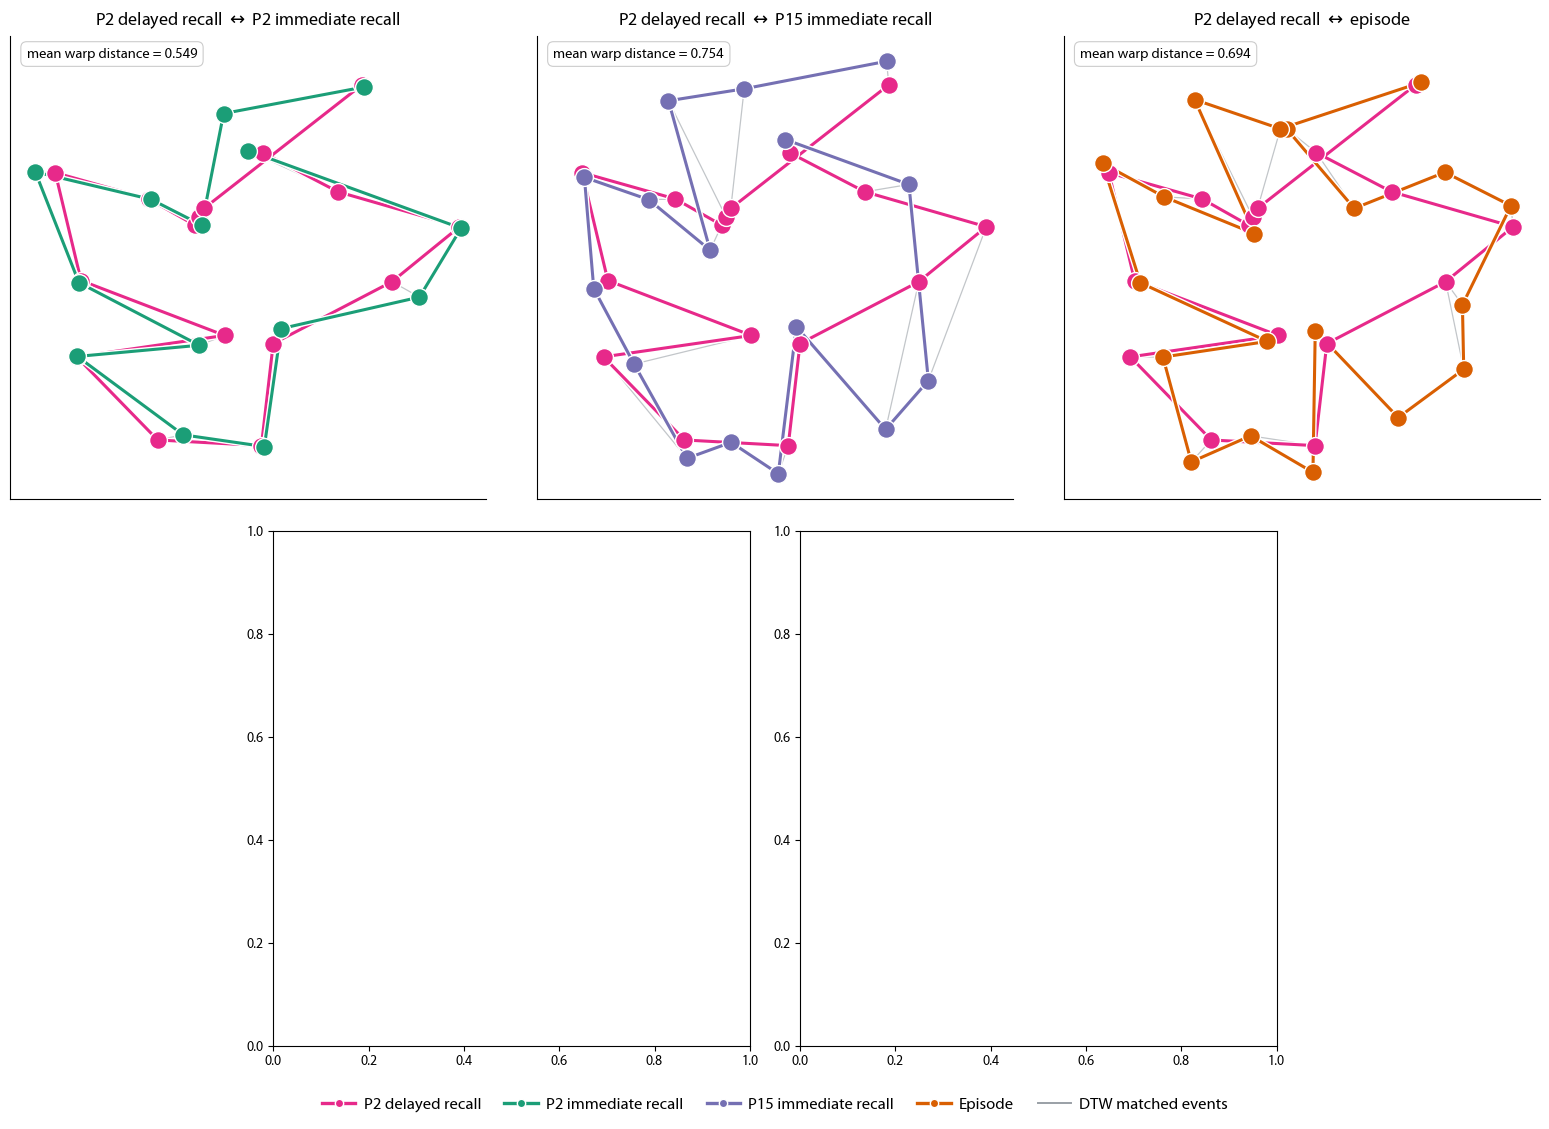

In [108]:
############################# STYLE CONFIG #############################

MAIN_PARTICIPANT_N = 2
OTHER_PARTICIPANT_N = 15

# ColorBrewer "Dark2" palette
MAIN_DEL_COLOR = "#E7298A"
MAIN_IMM_COLOR = "#1B9E77"
OTHER_IMM_COLOR = "#7570B3"
EPISODE_COLOR = "#D95F02"
WARP_LINE_COLOR = "#9AA0A6"

EVENT_MARKERSIZE = 165
EVENT_BORDER_WIDTH = 1

PATH_LINEWIDTH = 2.2
PATH_CASING_WIDTH = PATH_LINEWIDTH + 2
WARP_LINEWIDTH = 0.9
WARP_LINE_ALPHA = 0.6

XLIM_PAD = 5
YLIM_PAD = 5

TITLE_FONTSIZE = 13
TITLE_YPAD = 8

TEXTBOX_X = 0.035
TEXTBOX_Y = 0.975
TEXTBOX_FONTSIZE = 10.5



########################################################################

main_participant = participants[MAIN_PARTICIPANT_N - 1]
other_participant = participants[OTHER_PARTICIPANT_N - 1]

main_pid = f'P{MAIN_PARTICIPANT_N}'
other_pid = f'P{OTHER_PARTICIPANT_N}'

del_path = main_participant.paths_2d['delayed']
own_imm_path = main_participant.paths_2d['atlep1']
other_imm_path = other_participant.paths_2d['atlep1']
episode_path = atlep1.path_2d

own_imm_dist, own_imm_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
                                 imm_events_centered[MAIN_PARTICIPANT_N - 1], 
                                 metric='cosine', 
                                 norm_cost=True)
other_imm_dist, other_imm_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
                                     imm_events_centered[OTHER_PARTICIPANT_N - 1], 
                                     metric='cosine', 
                                     norm_cost=True)
episode_dist, episode_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
                                 ep_events_centered, 
                                 metric='cosine', 
                                 norm_cost=True)


# shared x,y-limits for 3 example panels
all_points = np.vstack((del_path, own_imm_path, other_imm_path, episode_path))

xlim_min, ylim_min = all_points.min(axis=0)
xlim_max, ylim_max = all_points.max(axis=0)
xlim_min -= XLIM_PAD
xlim_max += XLIM_PAD
ylim_min -= YLIM_PAD
ylim_max += YLIM_PAD


fig = plt.figure(figsize=(15.6, 11))
gs = fig.add_gridspec(nrows=2, ncols=6, hspace=0.28, wspace=0.55)

own_ax = fig.add_subplot(gs[0, 0:2])
other_ax = fig.add_subplot(gs[0, 2:4], sharex=own_ax, sharey=own_ax)
ep_ax = fig.add_subplot(gs[0, 4:6], sharex=own_ax, sharey=own_ax)

self_other_ax = fig.add_subplot(gs[1, 1:3])
self_ep_ax = fig.add_subplot(gs[1, 3:5])



# fig, axes = plt.subplots(1, 3, figsize=(5.2 * 3, 5.7),
#                          sharex=True, sharey=True)
# own_ax, other_ax, ep_ax = axes


# delayed vs own immediate
draw_warp(own_ax, del_path, own_imm_path, own_imm_warp)
draw_event_path(own_ax, del_path, MAIN_DEL_COLOR)
draw_event_path(own_ax, own_imm_path, MAIN_IMM_COLOR)
own_ax.set_xlim(xlim_min, xlim_max)
own_ax.set_ylim(ylim_min, ylim_max)
own_ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
own_ax.spines[['top', 'right']].set_visible(False)
own_ax.set_title(fr'P{MAIN_PARTICIPANT_N} delayed recall $\leftrightarrow$ P{MAIN_PARTICIPANT_N} immediate recall',
                 fontsize=TITLE_FONTSIZE, 
                 pad=TITLE_YPAD)
own_ax.text(TEXTBOX_X, 
            TEXTBOX_Y, 
            f'mean warp distance = {own_imm_dist:.3f}',
            transform=own_ax.transAxes, 
            ha="left", 
            va="top", 
            fontsize=TEXTBOX_FONTSIZE,
            bbox={'boxstyle': 'round,pad=0.4', 
                  'fc': 'white', 
                  'ec': '#cccccc', 
                  'lw': 0.8})

# delayed vs other immediate
draw_warp(other_ax, del_path, other_imm_path, other_imm_warp)
draw_event_path(other_ax, del_path, MAIN_DEL_COLOR)
draw_event_path(other_ax, other_imm_path, OTHER_IMM_COLOR)
other_ax.set_xlim(xlim_min, xlim_max)
other_ax.set_ylim(ylim_min, ylim_max)
other_ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
other_ax.spines[['top', 'right']].set_visible(False)
other_ax.set_title(fr'P{MAIN_PARTICIPANT_N} delayed recall $\leftrightarrow$ P{OTHER_PARTICIPANT_N} immediate recall',
                   fontsize=TITLE_FONTSIZE, 
                   pad=TITLE_YPAD)
other_ax.text(TEXTBOX_X, 
              TEXTBOX_Y, 
              f'mean warp distance = {other_imm_dist:.3f}',
              transform=other_ax.transAxes, 
              ha="left", 
              va="top", 
              fontsize=TEXTBOX_FONTSIZE,
              bbox={'boxstyle': 'round,pad=0.4', 
                    'fc': 'white', 
                    'ec': '#cccccc', 
                    'lw': 0.8})

# delayed vs episode
draw_warp(ep_ax, del_path, episode_path, episode_warp)
draw_event_path(ep_ax, del_path, MAIN_DEL_COLOR)
draw_event_path(ep_ax, episode_path, EPISODE_COLOR)
ep_ax.set_xlim(xlim_min, xlim_max)
ep_ax.set_ylim(ylim_min, ylim_max)
ep_ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
ep_ax.spines[['top', 'right']].set_visible(False)
ep_ax.set_title(fr'P{MAIN_PARTICIPANT_N} delayed recall $\leftrightarrow$ episode',
                fontsize=TITLE_FONTSIZE, 
                pad=TITLE_YPAD)
ep_ax.text(TEXTBOX_X, 
           TEXTBOX_Y, 
           f'mean warp distance = {episode_dist:.3f}',
           transform=ep_ax.transAxes, 
           ha="left", 
           va="top", 
           fontsize=TEXTBOX_FONTSIZE,
           bbox={'boxstyle': 'round,pad=0.4', 
                 'fc': 'white', 
                 'ec': '#cccccc', 
                 'lw': 0.8})

# shared legend
handles = [
    Line2D([0], [0], color=MAIN_DEL_COLOR, lw=2.4, marker="o", mfc=MAIN_DEL_COLOR,
           mec="white", label=f"P{MAIN_PARTICIPANT_N} delayed recall"),
    Line2D([0], [0], color=MAIN_IMM_COLOR, lw=2.4, marker="o", mfc=MAIN_IMM_COLOR,
           mec="white", label=f"P{MAIN_PARTICIPANT_N} immediate recall"),
    Line2D([0], [0], color=OTHER_IMM_COLOR, lw=2.4, marker="o", mfc=OTHER_IMM_COLOR,
           mec="white", label=f"P{OTHER_PARTICIPANT_N} immediate recall"),
    Line2D([0], [0], color=EPISODE_COLOR, lw=2.4, marker="o", mfc=EPISODE_COLOR,
           mec="white", label="Episode"),
    Line2D([0], [0], color=WARP_LINE_COLOR, lw=1.4, label="DTW matched events"),
]
fig.legend(handles=handles, loc="lower center", ncol=7, frameon=False,
           bbox_to_anchor=(0.5, -0.04), fontsize=12, handletextpad=0.5,
           columnspacing=1.4)

gs.tight_layout(fig)
# fig.tight_layout(rect=[0, 0.06, 1, 0.97])

# fig.suptitle(f"Example participant ({MAIN_LABEL}): DTW alignment of delayed recall "
#              f"to immediate recalls and to the episode", fontsize=13, y=1.0)
# fig.tight_layout(rect=[0, 0.06, 1, 0.97])
# fig.savefig(OUT_PATH, bbox_inches="tight", dpi=150)
# print(f"saved -> {OUT_PATH}")
plt.show()

In [111]:
from scipy.stats import wilcoxon
warp_dists_imm = []
warp_dists_episode = []

for imm_events, del_events in zip(imm_events_centered, del_events_centered):
    dist_imm = dtw(del_events, imm_events)[0]
    dist_ep = dtw(del_events, ep_events_centered)[0]
    warp_dists_imm.append(dist_imm)
    warp_dists_episode.append(dist_ep)
    
T, p = wilcoxon(warp_dists_episode, warp_dists_imm, alternative='greater')
T, p = T.item(), p.item()
print(f'mean immediate-alignment cost: {np.mean(warp_dists_imm):.4f}')
print(f'mean episode-alignment cost: {np.mean(warp_dists_episode):.4f}')
print(f'{T=}, {p=:.4e}')

mean immediate-alignment cost: 0.5321
mean episode-alignment cost: 0.6539
T=1430.0, p=1.2637e-10


In [113]:
warp_dists_self = np.array(warp_dists_imm[:])
warp_dists_others = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    del_events = del_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(del_events, imm_events_centered[j])[0]
            warp_dists_others[i, dists_ix] = warp_dist_other
            dists_ix += 1
            
pct_ranks = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others[i]
    pct_ranks[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)
    
print(wilcoxon(pct_ranks, 0.5, alternative='greater'))

WilcoxonResult(statistic=np.float64(1431.0), pvalue=np.float64(2.182214068738512e-11))


In [115]:
def _sig_bracket(ax, x1, x2, y, text, h):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="#333", lw=1.2)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=11, color="#333")

def draw_paired_panel(ax, a, b, color_a, color_b, xticklabels, T):
    a, b = np.asarray(a), np.asarray(b)
    for ai, bi in zip(a, b):
        consistent = bi >= ai
        ax.plot([0, 1], [ai, bi], color=WARP_LINE_COLOR if consistent else REVERSAL_COLOR,
                alpha=0.35 if consistent else 0.7, lw=1.0, zorder=1)
    ax.scatter(np.zeros(len(a)), a, s=GROUP_POINT_SIZE, color=color_a,
               edgecolor="white", lw=GROUP_POINT_EDGE_WIDTH, zorder=3)
    ax.scatter(np.ones(len(b)), b, s=GROUP_POINT_SIZE, color=color_b,
               edgecolor="white", lw=GROUP_POINT_EDGE_WIDTH, zorder=3)
    for x, vals in [(0, a), (1, b)]:
        m = np.median(vals)
        ax.plot([x - 0.16, x + 0.16], [m, m], color=MEDIAN_BAR_COLOR, lw=2.6,
                zorder=4, solid_capstyle="round")
    top = max(a.max(), b.max())
    _sig_bracket(ax, 0, 1, top + 0.02, fr"$T$ = {T}, $p$ < .001", h=0.018)
    ax.set_xlim(-0.5, 1.5); ax.set_xticks([0, 1]); ax.set_xticklabels(xticklabels)
    ax.set_ylim(min(a.min(), b.min()) - 0.03, top + 0.10)
    ax.set_ylabel("mean warp distance")
    ax.spines[["top", "right"]].set_visible(False)
    return ax

def draw_rank_panel(ax, ranks, color, T):
    ranks = np.asarray(ranks)
    for body in ax.violinplot(ranks, positions=[0], widths=0.75,
                              showextrema=False)["bodies"]:
        body.set_facecolor("#e9e9ee"); body.set_edgecolor("none"); body.set_alpha(1.0)
    jitter = np.random.default_rng(0).normal(0, 0.055, len(ranks))
    ax.scatter(jitter, ranks, s=GROUP_POINT_SIZE, color=color,
               edgecolor="white", lw=GROUP_POINT_EDGE_WIDTH, zorder=3)
    m = np.median(ranks)
    ax.plot([-0.19, 0.19], [m, m], color=MEDIAN_BAR_COLOR, lw=2.6, zorder=4, solid_capstyle="round")
    ax.axhline(0.5, ls=(0, (4, 3)), color=CHANCE_LINE_COLOR, lw=1.2, zorder=2)
    ax.text(0.57, 0.5, "chance", ha="right", va="center", color="#666", fontsize=9.5)
    ax.text(0, 1.05, fr"$T$ = {T}, $p$ < .001", ha="center", va="bottom", fontsize=11)
    ax.set_ylim(-0.02, 1.10); ax.set_xlim(-0.6, 0.6); ax.set_xticks([])
    ax.set_ylabel("percentile rank of own-immediate\ndistance (vs. others' immediate)")
    ax.spines[["top", "right"]].set_visible(False)
    return ax

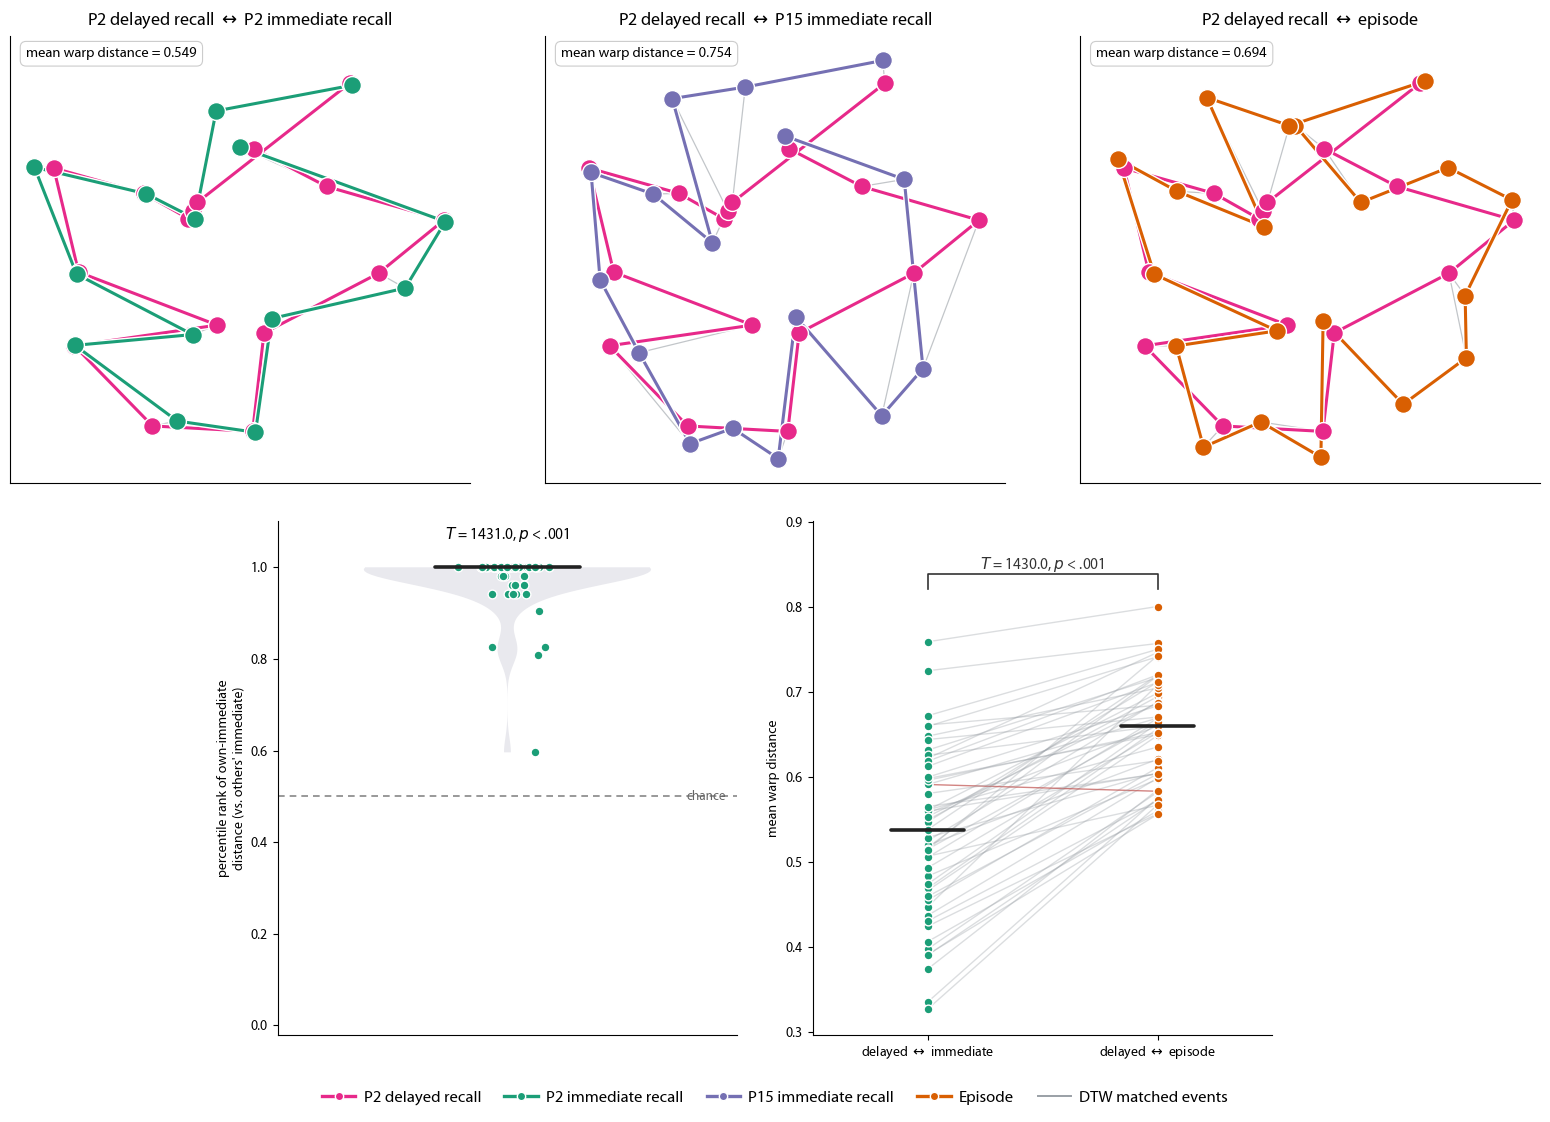

In [116]:
############################# STYLE CONFIG #############################

MAIN_PARTICIPANT_N = 2
OTHER_PARTICIPANT_N = 15

# ColorBrewer "Dark2" palette
MAIN_DEL_COLOR = "#E7298A"
MAIN_IMM_COLOR = "#1B9E77"
OTHER_IMM_COLOR = "#7570B3"
EPISODE_COLOR = "#D95F02"
WARP_LINE_COLOR = "#9AA0A6"

EVENT_MARKERSIZE = 165
EVENT_BORDER_WIDTH = 1

PATH_LINEWIDTH = 2.2
PATH_CASING_WIDTH = PATH_LINEWIDTH + 2
WARP_LINEWIDTH = 0.9
WARP_LINE_ALPHA = 0.6

XLIM_PAD = 5
YLIM_PAD = 5

TITLE_FONTSIZE = 13
TITLE_YPAD = 8

TEXTBOX_X = 0.035
TEXTBOX_Y = 0.975
TEXTBOX_FONTSIZE = 10.5



GROUP_POINT_SIZE = 40
GROUP_POINT_EDGE_WIDTH = 1.0
MEDIAN_BAR_COLOR = "#222222"
REVERSAL_COLOR = "#C0504D"
CHANCE_LINE_COLOR = "#888888"

########################################################################

main_participant = participants[MAIN_PARTICIPANT_N - 1]
other_participant = participants[OTHER_PARTICIPANT_N - 1]

main_pid = f'P{MAIN_PARTICIPANT_N}'
other_pid = f'P{OTHER_PARTICIPANT_N}'

del_path = main_participant.paths_2d['delayed']
own_imm_path = main_participant.paths_2d['atlep1']
other_imm_path = other_participant.paths_2d['atlep1']
episode_path = atlep1.path_2d

own_imm_dist, own_imm_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
                                 imm_events_centered[MAIN_PARTICIPANT_N - 1], 
                                 metric='cosine', 
                                 norm_cost=True)
other_imm_dist, other_imm_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
                                     imm_events_centered[OTHER_PARTICIPANT_N - 1], 
                                     metric='cosine', 
                                     norm_cost=True)
episode_dist, episode_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
                                 ep_events_centered, 
                                 metric='cosine', 
                                 norm_cost=True)


# shared x,y-limits for 3 example panels
all_points = np.vstack((del_path, own_imm_path, other_imm_path, episode_path))

xlim_min, ylim_min = all_points.min(axis=0)
xlim_max, ylim_max = all_points.max(axis=0)
xlim_min -= XLIM_PAD
xlim_max += XLIM_PAD
ylim_min -= YLIM_PAD
ylim_max += YLIM_PAD


fig = plt.figure(figsize=(15.6, 11))
gs = fig.add_gridspec(nrows=2, ncols=6, hspace=0.28, wspace=0.55)

own_ax = fig.add_subplot(gs[0, 0:2])
other_ax = fig.add_subplot(gs[0, 2:4], sharex=own_ax, sharey=own_ax)
ep_ax = fig.add_subplot(gs[0, 4:6], sharex=own_ax, sharey=own_ax)

self_other_ax = fig.add_subplot(gs[1, 1:3])
self_ep_ax = fig.add_subplot(gs[1, 3:5])



# fig, axes = plt.subplots(1, 3, figsize=(5.2 * 3, 5.7),
#                          sharex=True, sharey=True)
# own_ax, other_ax, ep_ax = axes


# delayed vs own immediate
draw_warp(own_ax, del_path, own_imm_path, own_imm_warp)
draw_event_path(own_ax, del_path, MAIN_DEL_COLOR)
draw_event_path(own_ax, own_imm_path, MAIN_IMM_COLOR)
own_ax.set_xlim(xlim_min, xlim_max)
own_ax.set_ylim(ylim_min, ylim_max)
own_ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
own_ax.spines[['top', 'right']].set_visible(False)
own_ax.set_title(fr'P{MAIN_PARTICIPANT_N} delayed recall $\leftrightarrow$ P{MAIN_PARTICIPANT_N} immediate recall',
                 fontsize=TITLE_FONTSIZE, 
                 pad=TITLE_YPAD)
own_ax.text(TEXTBOX_X, 
            TEXTBOX_Y, 
            f'mean warp distance = {own_imm_dist:.3f}',
            transform=own_ax.transAxes, 
            ha="left", 
            va="top", 
            fontsize=TEXTBOX_FONTSIZE,
            bbox={'boxstyle': 'round,pad=0.4', 
                  'fc': 'white', 
                  'ec': '#cccccc', 
                  'lw': 0.8})

# delayed vs other immediate
draw_warp(other_ax, del_path, other_imm_path, other_imm_warp)
draw_event_path(other_ax, del_path, MAIN_DEL_COLOR)
draw_event_path(other_ax, other_imm_path, OTHER_IMM_COLOR)
other_ax.set_xlim(xlim_min, xlim_max)
other_ax.set_ylim(ylim_min, ylim_max)
other_ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
other_ax.spines[['top', 'right']].set_visible(False)
other_ax.set_title(fr'P{MAIN_PARTICIPANT_N} delayed recall $\leftrightarrow$ P{OTHER_PARTICIPANT_N} immediate recall',
                   fontsize=TITLE_FONTSIZE, 
                   pad=TITLE_YPAD)
other_ax.text(TEXTBOX_X, 
              TEXTBOX_Y, 
              f'mean warp distance = {other_imm_dist:.3f}',
              transform=other_ax.transAxes, 
              ha="left", 
              va="top", 
              fontsize=TEXTBOX_FONTSIZE,
              bbox={'boxstyle': 'round,pad=0.4', 
                    'fc': 'white', 
                    'ec': '#cccccc', 
                    'lw': 0.8})

# delayed vs episode
draw_warp(ep_ax, del_path, episode_path, episode_warp)
draw_event_path(ep_ax, del_path, MAIN_DEL_COLOR)
draw_event_path(ep_ax, episode_path, EPISODE_COLOR)
ep_ax.set_xlim(xlim_min, xlim_max)
ep_ax.set_ylim(ylim_min, ylim_max)
ep_ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
ep_ax.spines[['top', 'right']].set_visible(False)
ep_ax.set_title(fr'P{MAIN_PARTICIPANT_N} delayed recall $\leftrightarrow$ episode',
                fontsize=TITLE_FONTSIZE, 
                pad=TITLE_YPAD)
ep_ax.text(TEXTBOX_X, 
           TEXTBOX_Y, 
           f'mean warp distance = {episode_dist:.3f}',
           transform=ep_ax.transAxes, 
           ha="left", 
           va="top", 
           fontsize=TEXTBOX_FONTSIZE,
           bbox={'boxstyle': 'round,pad=0.4', 
                 'fc': 'white', 
                 'ec': '#cccccc', 
                 'lw': 0.8})


draw_rank_panel(self_other_ax, pct_ranks, MAIN_IMM_COLOR, T=wilcoxon(pct_ranks, 0.5, alternative='greater')[0])

draw_paired_panel(self_ep_ax, warp_dists_imm, warp_dists_episode, MAIN_IMM_COLOR, EPISODE_COLOR,
                  [r"delayed $\leftrightarrow$ immediate", r"delayed $\leftrightarrow$ episode"], 
                  T=wilcoxon(warp_dists_episode, warp_dists_imm, alternative='greater')[0])


# shared legend
handles = [
    Line2D([0], [0], color=MAIN_DEL_COLOR, lw=2.4, marker="o", mfc=MAIN_DEL_COLOR,
           mec="white", label=f"P{MAIN_PARTICIPANT_N} delayed recall"),
    Line2D([0], [0], color=MAIN_IMM_COLOR, lw=2.4, marker="o", mfc=MAIN_IMM_COLOR,
           mec="white", label=f"P{MAIN_PARTICIPANT_N} immediate recall"),
    Line2D([0], [0], color=OTHER_IMM_COLOR, lw=2.4, marker="o", mfc=OTHER_IMM_COLOR,
           mec="white", label=f"P{OTHER_PARTICIPANT_N} immediate recall"),
    Line2D([0], [0], color=EPISODE_COLOR, lw=2.4, marker="o", mfc=EPISODE_COLOR,
           mec="white", label="Episode"),
    Line2D([0], [0], color=WARP_LINE_COLOR, lw=1.4, label="DTW matched events"),
]
fig.legend(handles=handles, loc="lower center", ncol=7, frameon=False,
           bbox_to_anchor=(0.5, -0.04), fontsize=12, handletextpad=0.5,
           columnspacing=1.4)

gs.tight_layout(fig)
# fig.tight_layout(rect=[0, 0.06, 1, 0.97])

# fig.suptitle(f"Example participant ({MAIN_LABEL}): DTW alignment of delayed recall "
#              f"to immediate recalls and to the episode", fontsize=13, y=1.0)
# fig.tight_layout(rect=[0, 0.06, 1, 0.97])
# fig.savefig(OUT_PATH, bbox_inches="tight", dpi=150)
# print(f"saved -> {OUT_PATH}")
plt.show()

In [119]:
own_imm_warp

[(0, 0),
 (1, 0),
 (2, 1),
 (3, 2),
 (4, 3),
 (5, 4),
 (6, 5),
 (7, 6),
 (8, 7),
 (9, 8),
 (10, 9),
 (11, 10),
 (12, 10),
 (13, 11),
 (14, 12),
 (15, 13)]

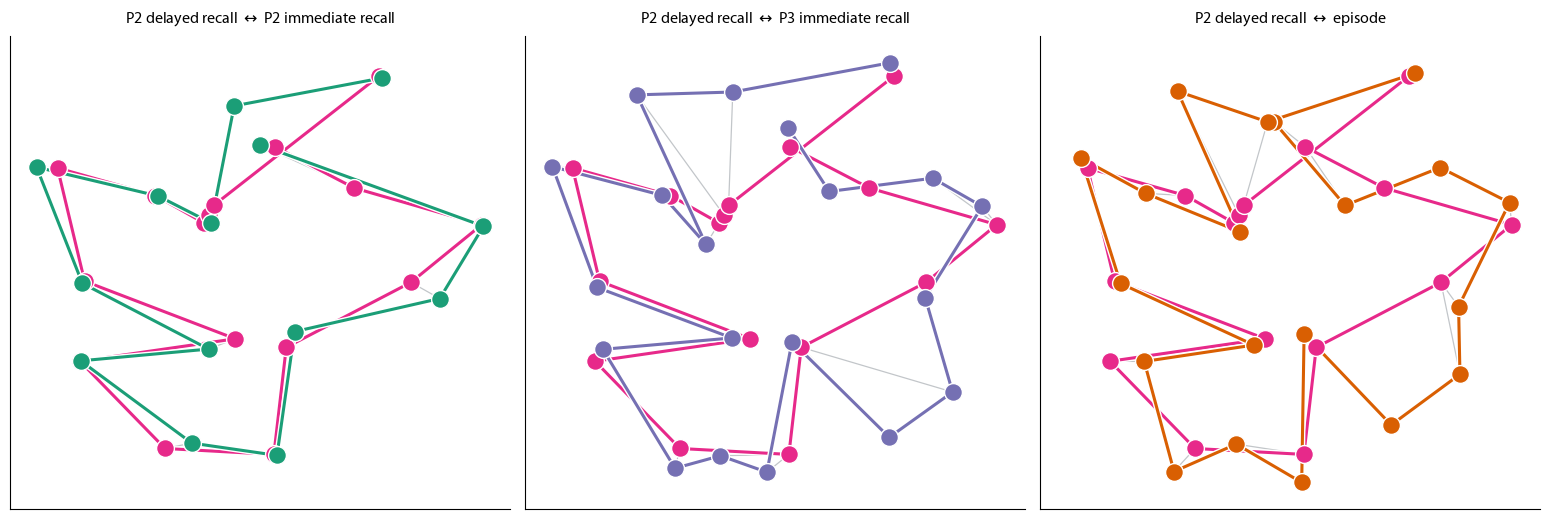

In [41]:
ax.spines.update

{'left': <matplotlib.spines.Spine at 0xffff56d85dc0>,
 'right': <matplotlib.spines.Spine at 0xffff56d87290>,
 'bottom': <matplotlib.spines.Spine at 0xffff56d873b0>,
 'top': <matplotlib.spines.Spine at 0xffff56d874d0>}

/tmp/ipykernel_5675/4037928513.py:150: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Myriad Pro.
  fig.tight_layout(rect=[0, 0.06, 1, 0.97])


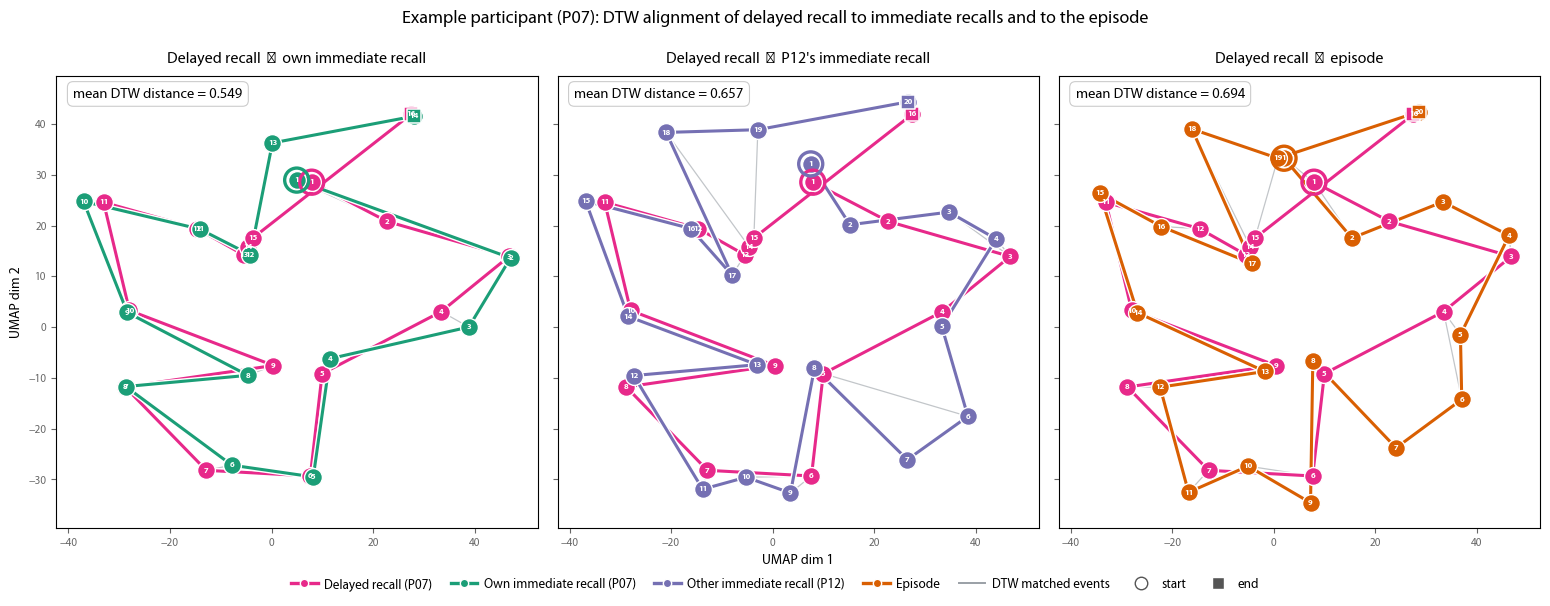

In [11]:
# """
# Three-panel DTW alignment figure.

# Illustrates one example participant's DELAYED recall event-path aligned (via the
# warp paths computed in the original 768-D space) to:
#     (1) their OWN immediate recall,
#     (2) a DIFFERENT participant's immediate recall,
#     (3) the EPISODE.

# All coordinates are the shared 2D UMAP projection; the gray connectors and the
# annotated mean DTW distances come from the high-dimensional analysis, not from
# these 2D points.

# ------------------------------------------------------------------------------
# To swap in a different example participant, edit the CONFIG block below:
# point `delayed`, `own_immediate`, `other_immediate`, `episode` at the new 2D
# paths, and `warp_*` / `dist_*` at that participant's warp paths and mean
# distances. Nothing below the CONFIG block needs to change.
# ------------------------------------------------------------------------------
# """
# import pickle
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patheffects as pe
# from matplotlib.lines import Line2D

# # ============================== CONFIG ======================================
# DATA_PATH   = "upload_data.p"

# MAIN_LABEL  = "P07"      # main example participant (delayed + own immediate)
# OTHER_LABEL = "P12"      # the "other" participant (immediate recall only)

# NUMBER_EVENTS = True     # numbers inside markers show temporal (event) order

# # palette: ColorBrewer "Dark2" (reasonably colour-vision-deficiency friendly)
# C_DELAYED = "#E7298A"    # delayed recall  -- the shared anchor, constant across panels
# C_OWN     = "#1B9E77"    # own immediate recall
# C_OTHER   = "#7570B3"    # other participant's immediate recall
# C_EPISODE = "#D95F02"    # episode
# C_WARP    = "#9AA0A6"    # DTW matched-event connectors

# with open(DATA_PATH, "rb") as f:
#     d = pickle.load(f)

# # tolerate the 'wrap_other' key typo in the pickle
# warp_other = d.get("warp_other", d.get("wrap_other"))

# delayed         = np.asarray(d["delayed_xy"])
# own_immediate   = np.asarray(d["own_immediate_xy"])
# other_immediate = np.asarray(d["other_immediate_xy"])
# episode         = np.asarray(d["episode_xy"])

# # One panel per row of this list. Reorder / edit freely.
# # `warp` entries are (delayed_index, cmp_index) pairs.
# PANELS = [
#     dict(cmp=own_immediate,   warp=d["warp_self"],    dist=d["dist_self"],
#          color=C_OWN,     title=f"Delayed recall  \u2194  own immediate recall"),
#     dict(cmp=other_immediate, warp=warp_other,        dist=d["dist_other"],
#          color=C_OTHER,   title=f"Delayed recall  \u2194  {OTHER_LABEL}'s immediate recall"),
#     dict(cmp=episode,         warp=d["warp_episode"], dist=d["dist_episode"],
#          color=C_EPISODE, title=f"Delayed recall  \u2194  episode"),
# ]
# # ===========================================================================

# # plt.rcParams.update({
# #     "font.family": "DejaVu Sans",
# #     "font.size": 11,
# #     "axes.spines.top": False,
# #     "axes.spines.right": False,
# #     "axes.linewidth": 0.8,
# #     "figure.dpi": 130,
# # })


# def draw_warp(ax, A, B, warp):
#     """Light connectors between DTW-matched events (drawn underneath paths)."""
#     for i, j in warp:
#         ax.plot([A[i, 0], B[j, 0]], [A[i, 1], B[j, 1]],
#                 color=C_WARP, lw=0.9, alpha=0.6, zorder=1, solid_capstyle="round")


# def draw_path(ax, P, color, number):
#     """A single event-path: white-cased line, markers, start ring, end square."""
#     # white casing under the coloured line so crossings stay legible
#     ax.plot(P[:, 0], P[:, 1], "-", color=color, lw=2.2, zorder=3,
#             solid_capstyle="round", solid_joinstyle="round",
#             path_effects=[pe.Stroke(linewidth=4.2, foreground="white"), pe.Normal()])
#     msize = 165 if number else 45
#     ax.scatter(P[:, 0], P[:, 1], s=msize, color=color, zorder=4,
#                edgecolor="white", linewidth=1.0)
#     # start = open ring, end = filled square
#     ax.scatter(*P[0],  s=300 if number else 170, facecolors="none",
#                edgecolors=color, linewidth=2.4, zorder=5)
#     ax.scatter(*P[-1], s=90, marker="s", color=color,
#                edgecolor="white", linewidth=1.1, zorder=6)
#     if number:
#         for k, (x, y) in enumerate(P):
#             ax.text(x, y, str(k + 1), color="white", fontsize=6.0,
#                     fontweight="bold", ha="center", va="center", zorder=7)


# # shared coordinate frame across all panels (single UMAP space)
# allpts = np.vstack([delayed] + [p["cmp"] for p in PANELS])
# padx = 0.06 * np.ptp(allpts[:, 0]) + 0.3
# pady = 0.06 * np.ptp(allpts[:, 1]) + 0.3
# xlim = (allpts[:, 0].min() - padx, allpts[:, 0].max() + padx)
# ylim = (allpts[:, 1].min() - pady, allpts[:, 1].max() + pady)

# fig, axes = plt.subplots(1, len(PANELS), figsize=(5.2 * len(PANELS), 5.7),
#                          sharex=True, sharey=True)

# for k, (ax, p) in enumerate(zip(axes, PANELS)):
#     draw_warp(ax, delayed, p["cmp"], p["warp"])
#     draw_path(ax, delayed, C_DELAYED, NUMBER_EVENTS)   # anchor on top-ish
#     draw_path(ax, p["cmp"], p["color"], NUMBER_EVENTS)
#     ax.set_title(p["title"], fontsize=11.5, pad=10)
#     ax.set_xlim(xlim); ax.set_ylim(ylim)
#     ax.set_aspect("equal", adjustable="box")
#     if k == len(PANELS) // 2:          # x-label on center panel only
#         ax.set_xlabel("UMAP dim 1")
#     ax.tick_params(labelsize=8, colors="#666")
#     ax.text(0.035, 0.975, f"mean DTW distance = {p['dist']:.3f}",
#             transform=ax.transAxes, ha="left", va="top", fontsize=10.5,
#             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", lw=0.8))

# axes[0].set_ylabel("UMAP dim 2")

# # shared legend
# handles = [
#     Line2D([0], [0], color=C_DELAYED, lw=2.4, marker="o", mfc=C_DELAYED,
#            mec="white", label=f"Delayed recall ({MAIN_LABEL})"),
#     Line2D([0], [0], color=C_OWN, lw=2.4, marker="o", mfc=C_OWN,
#            mec="white", label=f"Own immediate recall ({MAIN_LABEL})"),
#     Line2D([0], [0], color=C_OTHER, lw=2.4, marker="o", mfc=C_OTHER,
#            mec="white", label=f"Other immediate recall ({OTHER_LABEL})"),
#     Line2D([0], [0], color=C_EPISODE, lw=2.4, marker="o", mfc=C_EPISODE,
#            mec="white", label="Episode"),
#     Line2D([0], [0], color=C_WARP, lw=1.4, label="DTW matched events"),
#     Line2D([0], [0], color="#555", lw=0, marker="o", mfc="none", mec="#555",
#            markersize=9, label="start"),
#     Line2D([0], [0], color="#555", lw=0, marker="s", mfc="#555", mec="white",
#            markersize=8, label="end"),
# ]
# fig.legend(handles=handles, loc="lower center", ncol=7, frameon=False,
#            bbox_to_anchor=(0.5, -0.04), fontsize=9.5, handletextpad=0.5,
#            columnspacing=1.4)

# fig.suptitle(f"Example participant ({MAIN_LABEL}): DTW alignment of delayed recall "
#              f"to immediate recalls and to the episode", fontsize=13, y=1.0)
# fig.tight_layout(rect=[0, 0.06, 1, 0.97])
# # fig.savefig(OUT_PATH, bbox_inches="tight", dpi=150)
# # print(f"saved -> {OUT_PATH}")
# plt.show()

In [21]:
dist_self, warp_self = dtw(del_events_centered[1], imm_events_centered[1])
dist_other, warp_other = dtw(del_events_centered[1], imm_events_centered[2])
dist_episode, warp_episode = dtw(del_events_centered[1], ep_events_centered)

In [28]:
upload_data = {
    'delayed_xy': participants[1].paths_2d['delayed'],
    'own_immediate_xy': participants[1].paths_2d['atlep1'],
    'other_immediate_xy': participants[2].paths_2d['atlep1'],
    'episode_xy': atlep1.path_2d,
    'warp_self': warp_self,
    'warp_other': warp_other,
    'warp_episode': warp_episode,
    'dist_self': dist_self,
    'dist_other': dist_other,
    'dist_episode': dist_episode
}

In [29]:
upload_data

{'delayed_xy': array([[  7.9130526 ,  28.538652  ],
        [ 22.779154  ,  20.807922  ],
        [ 46.78058   ,  13.899035  ],
        [ 33.448936  ,   3.0481918 ],
        [  9.975465  ,  -9.186217  ],
        [  7.6452765 , -29.345959  ],
        [-12.85669   , -28.22753   ],
        [-28.845713  , -11.808084  ],
        [  0.37918562,  -7.5798345 ],
        [-27.993624  ,   3.269287  ],
        [-33.088142  ,  24.582008  ],
        [-14.641137  ,  19.389034  ],
        [ -5.4921007 ,  14.220136  ],
        [ -4.619841  ,  15.783893  ],
        [ -3.703975  ,  17.524364  ],
        [ 27.516283  ,  41.94208   ]], dtype=float32),
 'own_immediate_xy': array([[ 4.9612870e+00,  2.8950615e+01],
        [ 4.7096516e+01,  1.3612102e+01],
        [ 3.8871376e+01, -9.9717826e-04],
        [ 1.1537282e+01, -6.2303185e+00],
        [ 8.2266130e+00, -2.9529621e+01],
        [-7.8008523e+00, -2.7215790e+01],
        [-2.8724508e+01, -1.1724861e+01],
        [-4.6409197e+00, -9.5146790e+00],
     

In [30]:
import pickle
with open('upload_data.p', 'wb') as f:
    pickle.dump(upload_data, f)